In [2]:
import torch
from typing import Optional
import matplotlib.pyplot as plt

In [3]:
def visualize_mask(T, window_size):
    i = torch.arange(T).unsqueeze(1)
    j = torch.arange(T).unsqueeze(0)
    mask = ((j - i).abs() <= window_size // 2).float().numpy()

    plt.figure(figsize=(6, 6))
    plt.imshow(mask, cmap='Blues', interpolation='nearest')
    plt.title(f'Local Window Mask (T={T}, w={window_size})')
    plt.xlabel('Key position')
    plt.ylabel('Query position')
    plt.show()

In [4]:
def make_local_window_mask(T, window_size, device):
    i = torch.arange(T, device=device).unsqueeze(1)
    j = torch.arange(T, device=device).unsqueeze(0)
    mask = (j - i).abs() > window_size // 2
    return mask 

In [5]:
seq_len = 128
window_size = 12
device = 'cpu'

In [6]:
attention_mask = make_local_window_mask(seq_len, window_size, device)

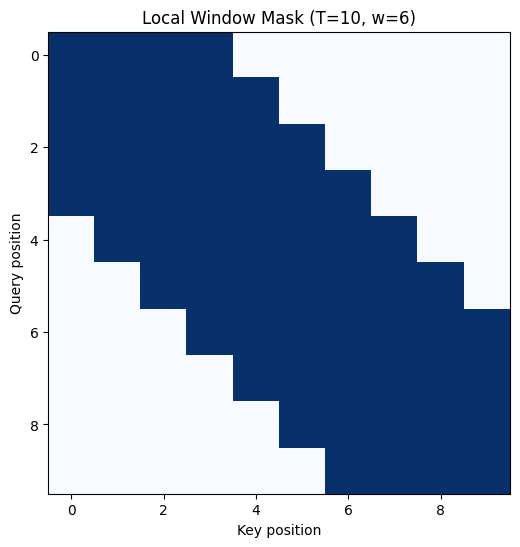

In [7]:
visualize_mask(T=10, window_size=6)

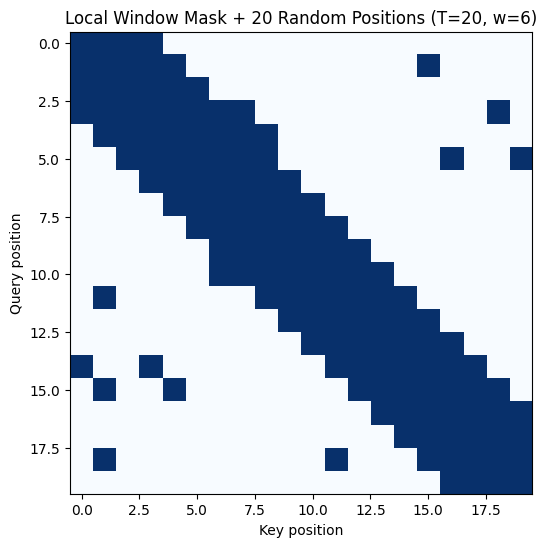

In [8]:
def visualize_mask(T, window_size, num_random=20):
    i = torch.arange(T).unsqueeze(1)
    j = torch.arange(T).unsqueeze(0)
    mask = ((j - i).abs() <= window_size // 2).float()

    # Add random positions
    rand_rows = torch.randint(0, T, (num_random,))
    rand_cols = torch.randint(0, T, (num_random,))
    mask[rand_rows, rand_cols] = 1.0

    plt.figure(figsize=(6, 6))
    plt.imshow(mask.numpy(), cmap='Blues', interpolation='nearest')
    plt.title(f'Local Window Mask + {num_random} Random Positions (T={T}, w={window_size})')
    plt.xlabel('Key position')
    plt.ylabel('Query position')
    plt.show()

visualize_mask(T=20, window_size=6, num_random=20)

In [15]:
def _prepare_local_attention_mask(
    attention_mask: Optional[torch.Tensor],
    window_size: int,
    dtype: torch.dtype,
) -> Optional[torch.Tensor]:
    """
    Combines a HF-style padding mask with a local window constraint into a
    single additive mask broadcastable over heads.

    Args:
        attention_mask: (B, T) with values in {0=ignore, 1=attend}, or None
        window_size:    Number of tokens each position can attend to.
                        Must be odd for a symmetric window; even values are
                        rounded up by 1 internally.
        dtype:          Target float dtype for the mask values.

    Returns:
        (B, 1, T, T) additive mask with 0.0 (attend) or -inf (ignore),
        or None if both inputs would produce an all-attend mask.
    """
    if attention_mask is None:
        return None

    B, T = attention_mask.shape
    device = attention_mask.device

    # --- 1. Local window mask (T, T) ---
    # Use (window_size - 1) // 2 for a symmetric half-radius that always
    # rounds toward the smaller side, keeping the total span == window_size.
    half = (window_size - 1) // 2
    i = torch.arange(T, device=device).unsqueeze(1)   # (T, 1)
    j = torch.arange(T, device=device).unsqueeze(0)   # (1, T)
    window_mask = (j - i).abs() > half                 # True = block (T, T)

    # --- 2. Padding mask (B, T) -> (B, 1, 1, T) ----------------------
    # Broadcast over (query positions, heads): a padding token is blocked
    # in every row of the attention matrix (it is never a valid key).
    padding_blocked = attention_mask == 0              # True = block (B, T)
    padding_mask = padding_blocked[:, None, None, :]   # (B, 1, 1, T)

    # --- 3. Combine: block if EITHER condition blocks ---
    # window_mask is (T, T), padding_mask is (B, 1, 1, T).
    # The union broadcasts to (B, 1, T, T).
    combined = window_mask.unsqueeze(0) | padding_mask  # (B, 1, T, T)

    # --- 4. Convert bool -> additive float mask ---
    attention_mask = torch.zeros(B, 1, T, T, dtype=dtype, device=device)
    attention_mask.masked_fill_(combined, torch.finfo(dtype).min)

    return attention_mask

In [24]:
attention_mask = torch.tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1 ,1, 1, 1, 1],
                              [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0],
                              [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0]])

attn_mask = _prepare_local_attention_mask(attention_mask, window_size=3, dtype=torch.float)

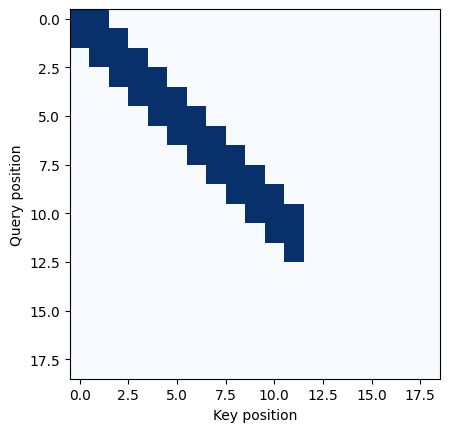

In [25]:
plt.imshow(attn_mask[2].squeeze(0).numpy(), cmap='Blues', interpolation='nearest')
plt.xlabel('Key position')
plt.ylabel('Query position')
plt.show()

In [20]:
attn_mask[0].squeeze(0).shape

torch.Size([19, 19])